# 03 · Cropping with context

**Goal:** give the language model the detected amenity *and* enough of its surroundings to ask useful questions, without the rest of the room.

A full hotel photo has a bed, curtains, a desk, a window and much more. Pass all of that to a language model and the questions drift away from the amenity. A tight crop has the opposite problem: a kettle without the counter next to it, or a bathtub without its taps, loses exactly the details a traveller cares about.

So every detected box is expanded by a fixed share of its own width and height, then clipped to the image:

```
pad_x = 0.35 · (x2 − x1)        pad_y = 0.35 · (y2 − y1)
x1' = max(0, x1 − pad_x)        y1' = max(0, y1 − pad_y)
x2' = min(W, x2 + pad_x)        y2' = min(H, y2 + pad_y)
```

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))

from amenity_qgen import config, plotting
from amenity_qgen.plotting import SERIES, MUTED, TEXT, TEXT_2

plotting.use_style()
pd.set_option("display.max_colwidth", 120)
FIG = ROOT / "results" / "figures"
AMENITIES = ["bathtub", "kettle", "hairdryer", "mirror", "tv"]
NAMES = {"bathtub": "Bathtub", "kettle": "Kettle", "hairdryer": "Hairdryer", "mirror": "Mirror", "tv": "TV"}

In [2]:
import inspect
from amenity_qgen.cropping import crop_box, safe_open_image
print(inspect.getsource(crop_box))

def crop_box(img: Image.Image, box, pad_frac: float = PAD_FRAC) -> Image.Image:
    """Crop [x1, y1, x2, y2] with proportional padding, clipped to the image."""
    w, h = img.size
    x1, y1, x2, y2 = box

    pad_x = pad_frac * (x2 - x1)
    pad_y = pad_frac * (y2 - y1)

    x1 = max(int(x1 - pad_x), 0)
    y1 = max(int(y1 - pad_y), 0)
    x2 = min(int(x2 + pad_x), w)
    y2 = min(int(y2 + pad_y), h)

    return img.crop((x1, y1, x2, y2))



## Choosing the padding
I tested several padding values on 50 detections across all five amenities:

- **10 to 20%:** too tight. Kettle crops lost the counter and sockets, hairdryer crops lost the wall mount, bathtub crops lost the taps and shower screen.
- **50% and above:** too loose. Doors, furniture and bare walls came back in, and the questions started to drift.
- **35%:** the best balance for every amenity. It keeps a TV in relation to the bed and a mirror with its lighting, while the amenity stays the main subject.

The same comparison on three of the user-study photos:

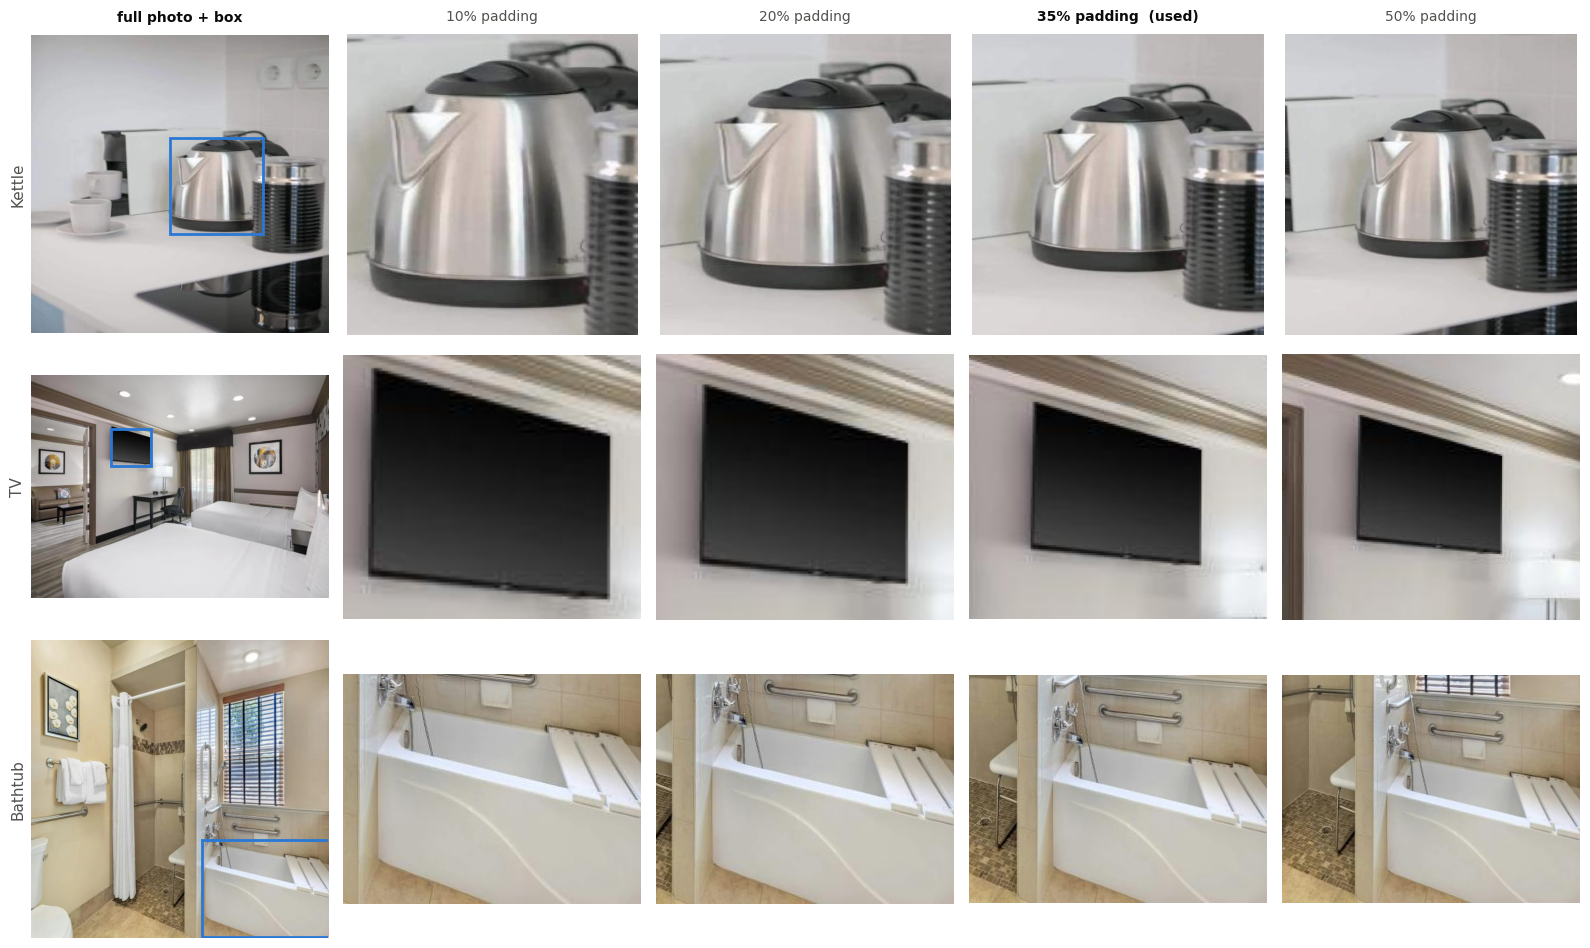

In [3]:
examples = [("kettle", "image_113_"), ("tv", "image_205_"), ("bathtub", "image_23_")]
pads = [0.10, 0.20, 0.35, 0.50]

fig, axes = plt.subplots(len(examples), len(pads) + 1, figsize=(16, 9.6))
for row, (am, prefix) in enumerate(examples):
    f = next(p for p in (ROOT / "data" / "user_study_images").iterdir() if p.name.startswith(f"{am}_{prefix}"))
    name, _ = config.AMENITIES[am]["selected"]
    dets = pd.read_csv(ROOT / "results" / "detection" / "raw_detections" / f"dets_{am}_{name}.csv")
    box = dets[dets.image == f.name[len(am) + 1:]].sort_values("score", ascending=False).iloc[0][["x1", "y1", "x2", "y2"]].tolist()
    img = safe_open_image(f)
    axes[row, 0].imshow(img); axes[row, 0].add_patch(plt.Rectangle(box[:2], box[2] - box[0], box[3] - box[1], fill=False, ec=SERIES[0], lw=2))
    axes[row, 0].set_title("full photo + box" if row == 0 else "", loc="center", fontsize=10)
    axes[row, 0].set_ylabel(NAMES[am], fontsize=11)
    for col, p in enumerate(pads, start=1):
        axes[row, col].imshow(crop_box(img, box, p))
        if row == 0:
            axes[row, col].set_title(f"{int(p * 100)}% padding" + ("  (used)" if p == 0.35 else ""), loc="center", fontsize=10,
                                     fontweight="bold" if p == 0.35 else "normal", color=TEXT if p == 0.35 else TEXT_2)
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for s in ax.spines.values(): s.set_visible(False)
plt.tight_layout(); fig.savefig(FIG / "crop_padding.png", dpi=100); plt.show()

## Takeaways
- Cropping is what makes the questions specific: the model sees the amenity and its immediate context, not the whole room.
- Every crop is RGB and saved as PNG before it goes to the model, so all runs and models get identical input.
- No detections were dropped at this step. Every detected amenity went on to question generation.